# structured / IMG_5982

このノートブックは、1本の動画についてフレーム確認、歪み補正の試行、ORB特徴点検出、隣接フレームのマッチング、特徴量ファイルの確認を行うための作業場所です。

In [10]:
# このセルでは、Notebook全体で使うライブラリ、入力データ、結果CSVの場所を定義します。
# structured/unstructured_like の比較では、同じ処理を別シーケンスに適用して数値差を見ます。
from pathlib import Path
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebookをどのディレクトリから起動しても、プロジェクト直下を見つけられるようにします。
# data/ と scripts/ が両方ある場所を、この研究リポジトリのルートとみなします。
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'scripts').exists():
            return candidate
    raise RuntimeError('Run this notebook from inside the my-research project.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())

# 解析対象の動画シーケンスです。
# structured は人工物や直線的な構造が多い環境、unstructured_like は自然物や不規則な模様が多い環境として比較します。
SEQUENCE = 'structured/IMG_5982'

# 10fpsに抽出済みのフレームを使います。SLAMやフレーム間マッチングでは、2fpsより時間差が小さい10fpsの方が追跡しやすいです。
FRAMES_ROOT = PROJECT_ROOT / 'data' / 'interim' / 'frames_10fps'

# export_orb_features.py が保存した ORB keypoint/descriptor の置き場所です。
FEATURES_ROOT = PROJECT_ROOT / 'results' / 'orb_features_n1000'

# evaluate_feature_budgets.py の集計結果です。特徴点数、マッチ数、通信量の比較に使います。
BUDGET_CSV = PROJECT_ROOT / 'results' / 'feature_budgets' / 'summary.csv'

# ORB-SLAM3用のカメラ設定です。現時点では近似値なので、精度評価前には実測キャリブレーション値に置き換えます。
CAMERA_CONFIG = PROJECT_ROOT / 'configs' / 'orbslam3' / 'iphone_vertical_1080x1920_approx.yaml'

# 対象シーケンスのフレーム一覧と、抽出時のメタデータを読み込みます。
# metadata には元動画のfps、解像度、総フレーム数、抽出後フレーム数などが入っています。
sequence_dir = FRAMES_ROOT / SEQUENCE
frame_paths = sorted(sequence_dir.glob('frame_*.jpg'))
metadata_path = sequence_dir / 'metadata.json'
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'SEQUENCE: {SEQUENCE}')
print(f'frames: {len(frame_paths)}')
metadata


PROJECT_ROOT: /Users/otsukamashu/univ-research/my-research
SEQUENCE: structured/IMG_5982
frames: 110


{'video': 'structured/IMG_5982.MOV',
 'status': 'ok',
 'target_fps': 10.0,
 'source_fps': 30.0,
 'source_frames': 330,
 'source_width': 1080,
 'source_height': 1920,
 'source_duration_sec': 11.0,
 'frames_written': 110}

## 代表フレーム

動画全体から等間隔にフレームを抜き出して、撮影状況を確認します。

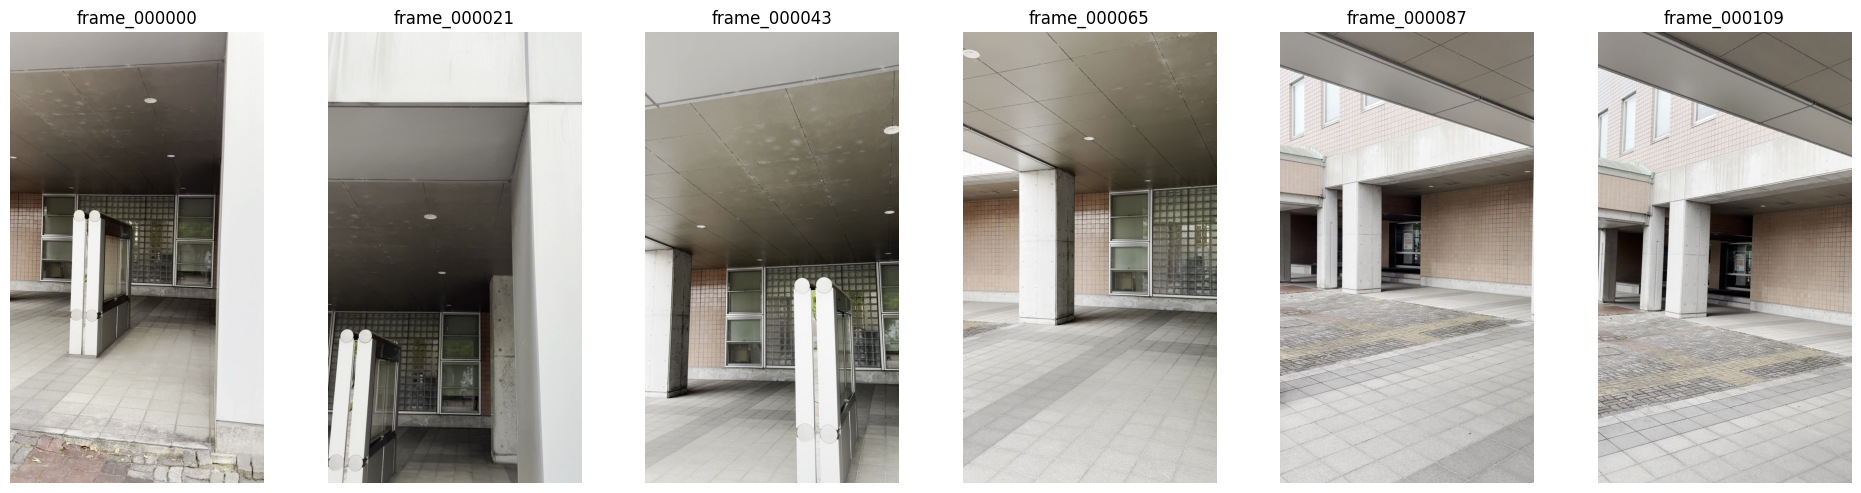

In [11]:
# フレームが無い場合は、以降の処理が意味を持たないためここで止めます。
if not frame_paths:
    raise FileNotFoundError(f'No frames found in {sequence_dir}')

# 動画全体の様子を偏りなく見るため、先頭から末尾まで等間隔に最大6枚を選びます。
indices = np.linspace(0, len(frame_paths) - 1, min(6, len(frame_paths)), dtype=int)
fig, axes = plt.subplots(1, len(indices), figsize=(3.2 * len(indices), 5))
if len(indices) == 1:
    axes = [axes]
for ax, index in zip(axes, indices):
    # OpenCVはBGR順で画像を読むため、matplotlib表示用にRGB順へ変換します。
    image = cv2.imread(str(frame_paths[index]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.set_title(frame_paths[index].stem)
    ax.axis('off')
plt.tight_layout()


## 特徴点数と通信量の概要

`scripts/evaluate_feature_budgets.py` の結果から、この動画の特徴点予算ごとの概算を見ます。

In [12]:
# 特徴点予算の集計CSVを読み込み、現在のシーケンスだけを取り出します。
# 1行が1つの nfeatures 設定に対応します。
budget = pd.read_csv(BUDGET_CSV)
sequence_budget = budget[budget['sequence'] == SEQUENCE].copy()
sequence_budget


,sequence,frames,nfeatures,avg_keypoints,min_keypoints,p10_keypoints,p90_keypoints,max_keypoints,avg_matches_to_previous,avg_good_matches_to_previous,avg_match_distance,avg_descriptor_bytes_per_frame,avg_compact_packet_bytes_per_frame,avg_float_packet_bytes_per_frame,avg_jpeg_bytes_per_frame,compact_packet_vs_jpeg_ratio
3,structured/IMG_5982,110,250,250.000,250,250.0,250.0,250,173.257,170.798,22.766,8000.000,10250.000,14000.000,464305.709,0.0221
11,structured/IMG_5982,110,500,500.000,500,500.0,500.0,500,337.394,333.266,23.362,16000.000,20500.000,28000.000,464305.709,0.0442
19,structured/IMG_5982,110,1000,1000.000,1000,1000.0,1000.0,1000,656.697,650.394,23.996,32000.000,41000.000,56000.000,464305.709,0.0883
27,structured/IMG_5982,110,2000,1999.209,1973,2000.0,2000.0,2000,1282.587,1270.706,25.037,63974.691,81967.573,111955.709,464305.709,0.1765


In [13]:
# 教授への説明で特に使う列だけを抜き出します。
# nfeatures: ORBで検出する特徴点数の上限。
# avg_keypoints: 実際に検出された特徴点数の平均。
# avg_good_matches_to_previous: 隣接フレーム間で、Hamming距離64以下だった良い対応点の平均。
# avg_compact_packet_bytes_per_frame: 量子化したkeypoint情報 + 32 byte descriptor を送る想定の通信量。
# avg_jpeg_bytes_per_frame: JPEGフレーム全体を送る場合の平均サイズ。
# compact_packet_vs_jpeg_ratio: 特徴点パケットがJPEG全体の何倍、または何割かを示す比率。
columns = [
    'nfeatures',
    'avg_keypoints',
    'avg_good_matches_to_previous',
    'avg_compact_packet_bytes_per_frame',
    'avg_jpeg_bytes_per_frame',
    'compact_packet_vs_jpeg_ratio',
]
sequence_budget[columns]


,nfeatures,avg_keypoints,avg_good_matches_to_previous,avg_compact_packet_bytes_per_frame,avg_jpeg_bytes_per_frame,compact_packet_vs_jpeg_ratio
3,250,250.000,170.798,10250.000,464305.709,0.0221
11,500,500.000,333.266,20500.000,464305.709,0.0442
19,1000,1000.000,650.394,41000.000,464305.709,0.0883
27,2000,1999.209,1270.706,81967.573,464305.709,0.1765


## ORB特徴点の可視化

`frame_index` と `nfeatures` を変えると、別フレームや別の特徴点数で確認できます。

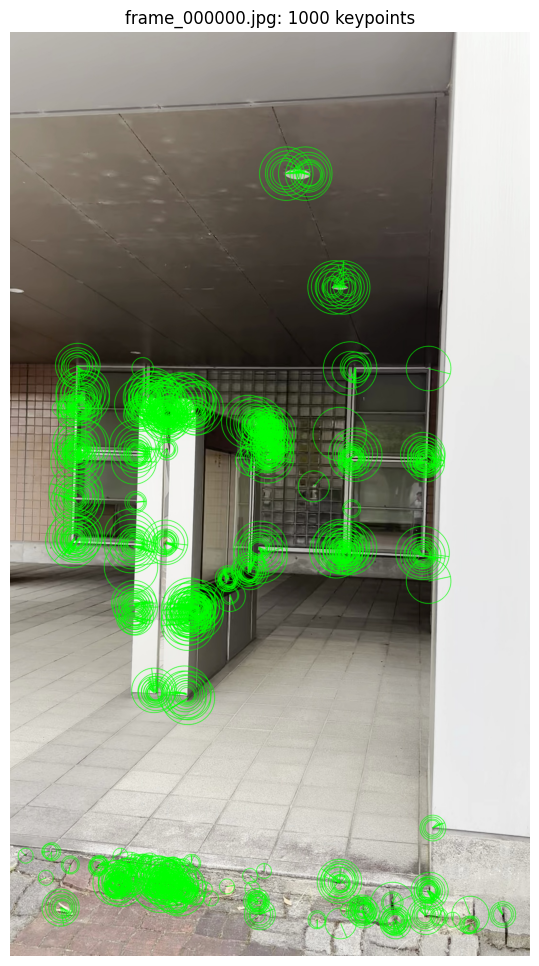

(1000, (1000, 32))

In [14]:
# 可視化したいフレーム番号と、ORB特徴点の上限数を指定します。
# nfeatures=1000 の場合、1フレームあたり最大1000個の特徴点を使います。
frame_index = 0
nfeatures = 1000

# ORBは輝度の変化を使うため、BGR画像をグレースケールに変換してから特徴点を検出します。
image_bgr = cv2.imread(str(frame_paths[frame_index]))
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# ORBの特徴点は、画像中の角・模様の変化・明暗差が大きい局所領域です。
# detectAndCompute は、keypoints と descriptors を同時に返します。
# keypoints: 座標、スケール、向き、応答値など。descriptors: 各点を表す32 byteのバイナリ特徴量。
orb = cv2.ORB_create(nfeatures=nfeatures)
keypoints, descriptors = orb.detectAndCompute(gray, None)

# DRAW_RICH_KEYPOINTS を使うと、特徴点の位置だけでなくスケールや向きも円・線で確認できます。
vis = cv2.drawKeypoints(
    image_bgr,
    keypoints,
    None,
    color=(0, 255, 0),
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS,
)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'{frame_paths[frame_index].name}: {len(keypoints)} keypoints')
plt.axis('off')
plt.show()

len(keypoints), None if descriptors is None else descriptors.shape


## 歪み補正の試行

ここでは処理の流れを確認するため、仮の内部パラメータとゼロ歪み係数を使っています。正確な歪み補正には、チェッカーボード等で実測したカメラキャリブレーション結果に置き換えてください。

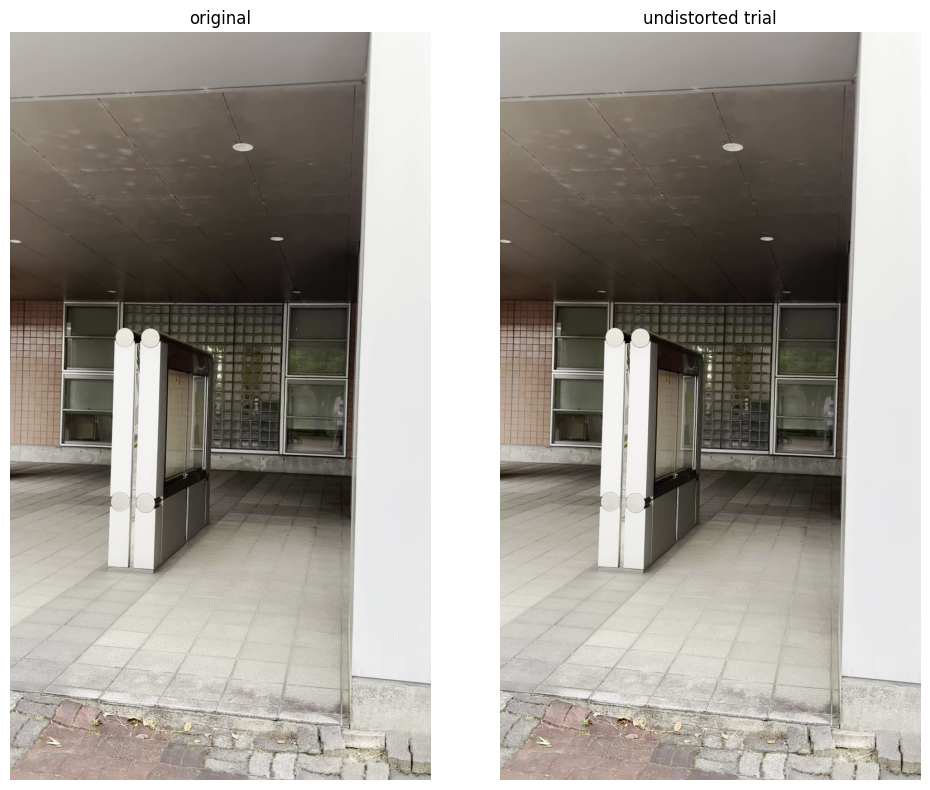

In [15]:
# 画像サイズから仮のカメラ内部パラメータを作ります。
# fx, fy は焦点距離、cx, cy は画像中心です。ここではまだ実測値ではありません。
height, width = image_bgr.shape[:2]
camera_matrix = np.array(
    [[1500.0, 0.0, width / 2], [0.0, 1500.0, height / 2], [0.0, 0.0, 1.0]],
    dtype=np.float32,
)
# 歪み係数をゼロにしているため、この補正は正確な補正ではなく処理確認用です。
dist_coeffs = np.zeros(5, dtype=np.float32)
# cv2.undistort は、内部パラメータと歪み係数からレンズ歪みを補正します。
undistorted = cv2.undistort(image_bgr, camera_matrix, dist_coeffs)

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
axes[1].set_title('undistorted trial')
axes[1].axis('off')
plt.tight_layout()


## 隣接フレームのマッチング

隣り合う2フレーム間でORB特徴量を対応付け、追跡しやすい映像かを確認します。

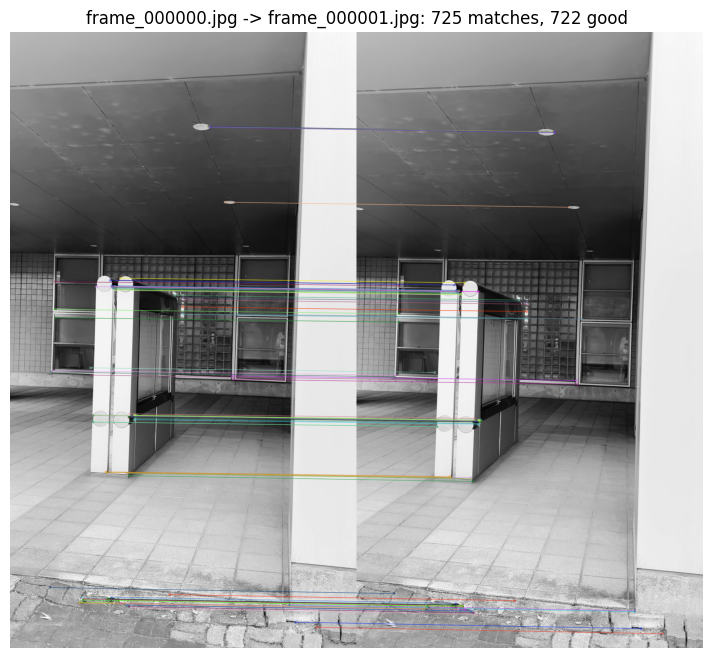

(1000, 1000, 725, 722)

In [16]:
# 隣接する2フレームを選び、同じ場所に対応しているORB特徴点を探します。
# structured と unstructured_like の比較では、このマッチ数と距離が重要です。
i = 0
j = min(i + 1, len(frame_paths) - 1)
img1_gray = cv2.imread(str(frame_paths[i]), cv2.IMREAD_GRAYSCALE)
img2_gray = cv2.imread(str(frame_paths[j]), cv2.IMREAD_GRAYSCALE)

# 2枚それぞれでORB特徴点と32 byteのdescriptorを抽出します。
kp1, des1 = orb.detectAndCompute(img1_gray, None)
kp2, des2 = orb.detectAndCompute(img2_gray, None)

# ORB descriptor はバイナリ列なので、距離には Hamming距離を使います。
# crossCheck=True は、1->2 と 2->1 の両方向で最良対応になったものだけを残す設定です。
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = [] if des1 is None or des2 is None else matcher.match(des1, des2)

# distance が小さいほどdescriptorが似ています。ここでは見やすいよう距離順に並べます。
matches = sorted(matches, key=lambda match: match.distance)
# good_matches は、通信量を削った後も姿勢推定に使えそうな対応点の目安です。
# しきい値64は evaluate_feature_budgets.py と同じ基準です。
good_matches = [match for match in matches if match.distance <= 64]

drawn = cv2.drawMatches(
    img1_gray,
    kp1,
    img2_gray,
    kp2,
    matches[:80],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(14, 8))
plt.imshow(drawn, cmap='gray')
plt.title(f'{frame_paths[i].name} -> {frame_paths[j].name}: {len(matches)} matches, {len(good_matches)} good')
plt.axis('off')
plt.show()

len(kp1), len(kp2), len(matches), len(good_matches)


## 保存済み特徴量ファイルの確認

`scripts/export_orb_features.py` で作った `.npz` を読み込み、送信対象になる特徴点と記述子を確認します。

In [17]:
# export_orb_features.py で保存した特徴量ファイルを確認します。
# 協調SLAMでは、画像そのものではなく、このkeypoints/descriptorsを送る想定です。
feature_file = FEATURES_ROOT / SEQUENCE / f'{frame_paths[frame_index].stem}.npz'
with np.load(feature_file) as feature_data:
    # keypoints は [x, y, size, angle, response, octave, class_id] の形で保存されています。
    saved_keypoints = feature_data['keypoints']
    # descriptors は ORBの32 byteバイナリ記述子です。shape は [特徴点数, 32] になります。
    saved_descriptors = feature_data['descriptors']

feature_file, saved_keypoints.shape, saved_descriptors.shape, saved_descriptors.dtype


(PosixPath('/Users/otsukamashu/univ-research/my-research/results/orb_features_n1000/structured/IMG_5982/frame_000000.npz'),
 (1000, 7),
 (1000, 32),
 dtype('uint8'))

## Essential Matrixの最小確認

仮のカメラ内部パラメータなので、ここでの値は精度評価ではなく、処理パイプラインの確認用です。

In [18]:
# Essential Matrixは、2枚の画像間の相対的なカメラ姿勢を推定するための行列です。
# 最低限8点程度の対応点が必要なので、マッチ数が足りない場合は推定しません。
if len(matches) >= 8:
    # queryIdx は1枚目の特徴点番号、trainIdx は2枚目の特徴点番号です。
    # OpenCVのfindEssentialMatに渡すため、対応点の2D座標だけを取り出します。
    pts1 = np.float32([kp1[match.queryIdx].pt for match in matches])
    pts2 = np.float32([kp2[match.trainIdx].pt for match in matches])
    # RANSACにより、外れ値のマッチを除きながらEssential Matrixを推定します。
    # threshold=1.0 は、再投影誤差に対する許容幅の目安です。
    essential_matrix, inlier_mask = cv2.findEssentialMat(
        pts1,
        pts2,
        camera_matrix,
        method=cv2.RANSAC,
        prob=0.999,
        threshold=1.0,
    )
    # inliers は、RANSACで幾何的に正しいと判断された対応点数です。
    # 次の評価では、このinlier数やinlier率を structured/unstructured_like で比較します。
    inliers = int(inlier_mask.sum()) if inlier_mask is not None else 0
else:
    essential_matrix = None
    inliers = 0

inliers, None if essential_matrix is None else essential_matrix.shape


(628, (3, 3))